In [4]:
# Mount Google Drive to access files.
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


https://www.kaggle.com/competitions/facebook-recruiting-iv-human-or-bot


There are two datasets in this competition. One is a bidder dataset that includes a list of bidder information, including their id, payment account, and address. The other is a bid dataset that includes 7.6 million bids on different auctions. The bids in this dataset are all made by mobile devices.

The online auction platform has a fixed increment of dollar amount for each bid, so it doesn't include an amount for each bid. You are welcome to learn the bidding behavior from the time of the bids, the auction, or the device.

The data in this competition comes from an online platform, not from Facebook.

File descriptions
train.csv - the training set from the bidder dataset
test.csv - the test set from the bidder dataset
sampleSubmission.csv - a sample submission file in the correct format
bids.csv - the bid dataset
Data fields
For the bidder dataset

bidder_id – Unique identifier of a bidder.
payment_account – Payment account associated with a bidder. These are obfuscated to protect privacy.
address – Mailing address of a bidder. These are obfuscated to protect privacy.
outcome – Label of a bidder indicating whether or not it is a robot. Value 1.0 indicates a robot, where value 0.0 indicates human.
The outcome was half hand labeled, half stats-based. There are two types of "bots" with different levels of proof:

1. Bidders who are identified as bots/fraudulent with clear proof. Their accounts were banned by the auction site.

2. Bidder who may have just started their business/clicks or their stats exceed from system wide average. There are no clear proof that they are bots.



For the bid dataset

bid_id - unique id for this bid
bidder_id – Unique identifier of a bidder (same as the bidder_id used in train.csv and test.csv)
auction – Unique identifier of an auction
merchandise –  The category of the auction site campaign, which means the bidder might come to this site by way of searching for "home goods" but ended up bidding for "sporting goods" - and that leads to this field being "home goods". This categorical field could be a search term, or online advertisement.
device – Phone model of a visitor
time - Time that the bid is made (transformed to protect privacy).
country - The country that the IP belongs to
ip – IP address of a bidder (obfuscated to protect privacy).
url - url where the bidder was referred from (obfuscated to protect privacy).

In [5]:
# Check if the dataset folder exists and list its contents.
import os

folder_path = '/content/gdrive/My Drive/human or robot dataset/dataset'

if os.path.exists(folder_path):
    print("✅ Folder exists\n")
    print("Files inside:")
    for file in os.listdir(folder_path):
        print(file)
else:
    print("❌ Folder path does NOT exist")

✅ Folder exists

Files inside:
bids.csv
test.csv
train.csv
datasets


In [6]:
# Load the 'bids.csv' and 'train.csv' datasets into pandas DataFrames.
import pandas as pd
import os

# 1. Paths
folder_path = '/content/gdrive/My Drive/human or robot dataset/dataset'
bids_path = os.path.join(folder_path, 'bids.csv')
train_path = os.path.join(folder_path, 'train.csv')

# Load datasets
bids_df = pd.read_csv(bids_path)
train_df = pd.read_csv(train_path)

In [7]:
# Display information (column names, non-null counts, dtypes) for train_df and bids_df.
print("--- TRAIN DATASET INFO ---")
print(train_df.info())
print("\n--- BIDS DATASET INFO ---")
print(bids_df.info())

--- TRAIN DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2013 entries, 0 to 2012
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bidder_id        2013 non-null   object 
 1   payment_account  2013 non-null   object 
 2   address          2013 non-null   object 
 3   outcome          2013 non-null   float64
dtypes: float64(1), object(3)
memory usage: 63.0+ KB
None

--- BIDS DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7656334 entries, 0 to 7656333
Data columns (total 9 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   bid_id       int64 
 1   bidder_id    object
 2   auction      object
 3   merchandise  object
 4   device       object
 5   time         int64 
 6   country      object
 7   ip           object
 8   url          object
dtypes: int64(2), object(7)
memory usage: 525.7+ MB
None


In [8]:
# Display descriptive statistics for train_df and bids_df.
print("\n--- TRAIN STATS ---")
display(train_df.describe(include='all'))

print("\n--- BIDS STATS ---")
display(bids_df.describe())


--- TRAIN STATS ---


,bidder_id,payment_account,address,outcome
count,2013,2013,2013,2013.000000
unique,2013,2013,2013,NaN
top,84a769adc98498f52debfe57b93a0789556f4,fbe0ce34d6546ebd9e4c63afc68b085byd2tf,a3d2de7675556553a5f08e4c88d2c228fib6p,NaN
freq,1,1,1,NaN
mean,NaN,NaN,NaN,0.051167
std,NaN,NaN,NaN,0.220394
min,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,0.000000



--- BIDS STATS ---


,bid_id,time
count,7.656334e+06,7.656334e+06
mean,3.828166e+06,9.697978e+15
std,2.210193e+06,5.250518e+13
min,0.000000e+00,9.631917e+15
25%,1.914083e+06,9.641139e+15
50%,3.828166e+06,9.700654e+15
75%,5.742250e+06,9.761744e+15
max,7.656333e+06,9.772885e+15


In [9]:
# Display the first 5 rows of train_df and bids_df.
print("\n--- TRAIN HEAD ---")
display(train_df.head())

print("\n--- BIDS HEAD ---")
display(bids_df.head())


--- TRAIN HEAD ---


,bidder_id,payment_account,address,outcome
0,91a3c57b13234af24875c56fb7e2b2f4rb56a,a3d2de7675556553a5f08e4c88d2c228754av,a3d2de7675556553a5f08e4c88d2c228vt0u4,0.0
1,624f258b49e77713fc34034560f93fb3hu3jo,a3d2de7675556553a5f08e4c88d2c228v1sga,ae87054e5a97a8f840a3991d12611fdcrfbq3,0.0
2,1c5f4fc669099bfbfac515cd26997bd12ruaj,a3d2de7675556553a5f08e4c88d2c2280cybl,92520288b50f03907041887884ba49c0cl0pd,0.0
3,4bee9aba2abda51bf43d639013d6efe12iycd,51d80e233f7b6a7dfdee484a3c120f3b2ita8,4cb9717c8ad7e88a9a284989dd79b98dbevyi,0.0
4,4ab12bc61c82ddd9c2d65e60555808acqgos1,a3d2de7675556553a5f08e4c88d2c22857ddh,2a96c3ce94b3be921e0296097b88b56a7x1ji,0.0



--- BIDS HEAD ---


,bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
0,0,8dac2b259fd1c6d1120e519fb1ac14fbqvax8,ewmzr,jewelry,phone0,9759243157894736,us,69.166.231.58,vasstdc27m7nks3
1,1,668d393e858e8126275433046bbd35c6tywop,aeqok,furniture,phone1,9759243157894736,in,50.201.125.84,jmqlhflrzwuay9c
2,2,aa5f360084278b35d746fa6af3a7a1a5ra3xe,wa00e,home goods,phone2,9759243157894736,py,112.54.208.157,vasstdc27m7nks3
3,3,3939ac3ef7d472a59a9c5f893dd3e39fh9ofi,jefix,jewelry,phone4,9759243157894736,in,18.99.175.133,vasstdc27m7nks3
4,4,8393c48eaf4b8fa96886edc7cf27b372dsibi,jefix,jewelry,phone5,9759243157894736,in,145.138.5.37,vasstdc27m7nks3


In [10]:
# Perform feature engineering and pre-aggregation for bidder-level EDA and modeling.
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. Data Loading ---
folder_path = '/content/gdrive/My Drive/human or robot dataset/dataset'
bids_df = pd.read_csv(os.path.join(folder_path, 'bids.csv'))
train_df = pd.read_csv(os.path.join(folder_path, 'train.csv'))

# --- 2. Basic Data Cleaning ---
# Dropping high-cardinality/unnecessary columns from train_df
train_df = train_df.drop(columns=['payment_account', 'address'])

# Merge target variable ('outcome') into bids for granular analysis
merged_bids = bids_df.merge(train_df[['bidder_id', 'outcome']], on='bidder_id', how='left')

# ==========================================
# 3. Pre-Aggregation for Bidder-Level EDA
# ==========================================
print("Pre-Aggregation for Bidder-Level EDA...")

# A. Basic Aggregations (Counts)
agg_funcs = {
    'bid_id': 'count',
    'auction': 'nunique',
    'device': 'nunique',
    'country': 'nunique',
    'ip': 'nunique',
    'url': 'nunique'
}

master_df = bids_df.groupby('bidder_id').agg(agg_funcs).reset_index()
master_df.columns = [
    'bidder_id', 'num_bids', 'num_auct', 'num_device',
    'num_country', 'num_ip', 'num_url'
]

# B. Temporal Features (Time Differences & Concurrent Bids)
# Sorting is critical for accurate time difference calculation
bids_df = bids_df.sort_values(by=['bidder_id', 'time'])
bids_df['time_diff'] = bids_df.groupby('bidder_id')['time'].diff()

time_stats = bids_df.groupby('bidder_id').agg(
    mean_diff=('time_diff', 'mean'),
    median_diff=('time_diff', 'median'),
    min_diff=('time_diff', 'min')
).reset_index()

# Calculate concurrent bids (where time_diff is 0)
concurrent = bids_df[bids_df['time_diff'] == 0].groupby('bidder_id').size().reset_index(name='num_concurrent_bids')
time_stats = time_stats.merge(concurrent, on='bidder_id', how='left').fillna(0)

# C. Missingness Feature
missing_country = bids_df[bids_df['country'].isnull()].groupby('bidder_id').size().reset_index(name='missing_country_bids')

# Combine engineered features into master_df
master_df = master_df.merge(time_stats, on='bidder_id', how='left')
master_df = master_df.merge(missing_country, on='bidder_id', how='left').fillna(0)

# Keep only labeled training data for EDA/Modeling
master_df = master_df.merge(train_df, on='bidder_id', how='inner')

# D. Advanced Ratios (Common in Fraud/Robot Detection)
master_df['percent_concurrent_bids'] = master_df['num_concurrent_bids'] / master_df['num_bids']
master_df['bids_per_device'] = master_df['num_bids'] / master_df['num_device']
master_df['bids_per_url'] = master_df['num_bids'] / master_df['num_url']

# Add 1 to denominator to prevent division by zero for countries
master_df['ip_per_ctry'] = master_df['num_ip'] / (master_df['num_country'] + 1)
master_df['device_per_auct'] = master_df['num_device'] / master_df['num_auct']

print(f"Pre-Aggregation Complete. Master Table Shape: {master_df.shape}")

Pre-Aggregation for Bidder-Level EDA...
Pre-Aggregation Complete. Master Table Shape: (1984, 18)


In [11]:
# Save the master_df DataFrame to a CSV file and download it.
# Save DataFrame to CSV
file_name = "master_df.csv"
master_df.to_csv(file_name, index=False)

# Download the file to your local computer
from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Display the number of rows and columns in master_df, and list all column names.
# Number of rows and columns
rows, cols = master_df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

# List all column names
print("\nColumn names in master_df:")
for col in master_df.columns:
    print(col)

Number of rows: 1984
Number of columns: 18

Column names in master_df:
bidder_id
num_bids
num_auct
num_device
num_country
num_ip
num_url
mean_diff
median_diff
min_diff
num_concurrent_bids
missing_country_bids
outcome
percent_concurrent_bids
bids_per_device
bids_per_url
ip_per_ctry
device_per_auct


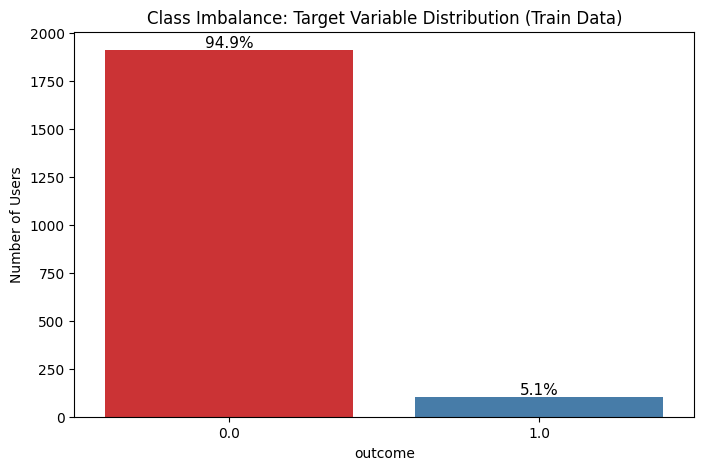

In [13]:
# Visualize the class imbalance of the 'outcome' variable in the training data.
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='outcome', data=train_df, palette='Set1')
plt.title('Class Imbalance: Target Variable Distribution (Train Data)')
plt.ylabel('Number of Users')

total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.show()

 The basic countplot exposes a severe class imbalance within the training dataset, indicating that humans heavily outnumber bots. This visualizes the fundamental challenge of the project, dictating that simple accuracy will be a misleading metric. The predictive model will require specialized evaluation methods, like the AUC-ROC curve, to accurately measure its ability to detect the minority bot class.

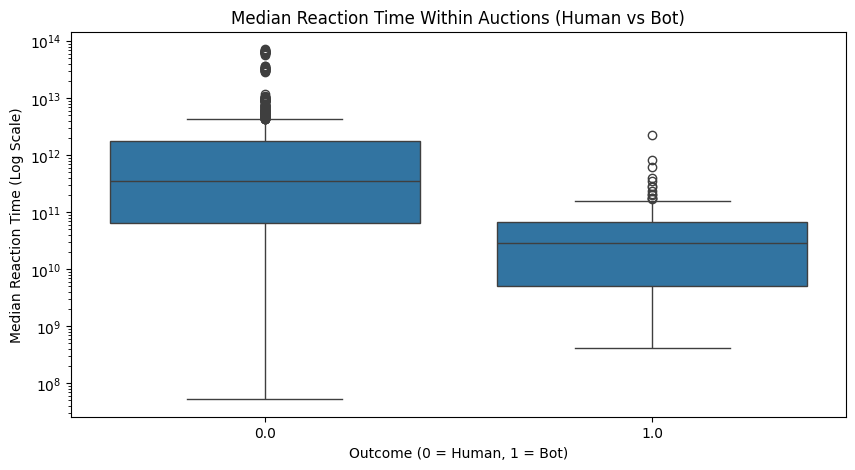

In [14]:
# Step 1: Sort bids by bidder, auction, and time
bids_sorted = bids_df.sort_values(['bidder_id', 'auction', 'time'])

# Step 2: Calculate time difference between consecutive bids
# within the same auction for the same bidder
bids_sorted['reaction_time'] = bids_sorted.groupby(
    ['bidder_id', 'auction']
)['time'].diff()

# Step 3: For each bidder compute their typical reaction time
reaction_summary = (
    bids_sorted.groupby('bidder_id')['reaction_time']
    .median()
    .reset_index()
)

# Step 4: Merge with outcome labels (human vs bot)
reaction_summary = reaction_summary.merge(
    train_df[['bidder_id','outcome']],
    on='bidder_id',
    how='left'
)

# Step 5: Plot comparison
plt.figure(figsize=(10,5))
sns.boxplot(x='outcome', y='reaction_time', data=reaction_summary)
plt.yscale('log')

plt.title('Median Reaction Time Within Auctions (Human vs Bot)')
plt.xlabel('Outcome (0 = Human, 1 = Bot)')
plt.ylabel('Median Reaction Time (Log Scale)')

plt.show()

The graph shows that Human behavior is predictable, while Bot behavior is extreme and varied.

Human Box (Outcome 0): The box is relatively small and sits higher up. This means most humans have a "normal" reaction time. They aren't bidding every millisecond, and they aren't waiting 10 days between bids. They are consistent.

Bot Box (Outcome 1): The box is massive. It stretches from very low values to very high values. This tells us that there isn't just one type of bot.

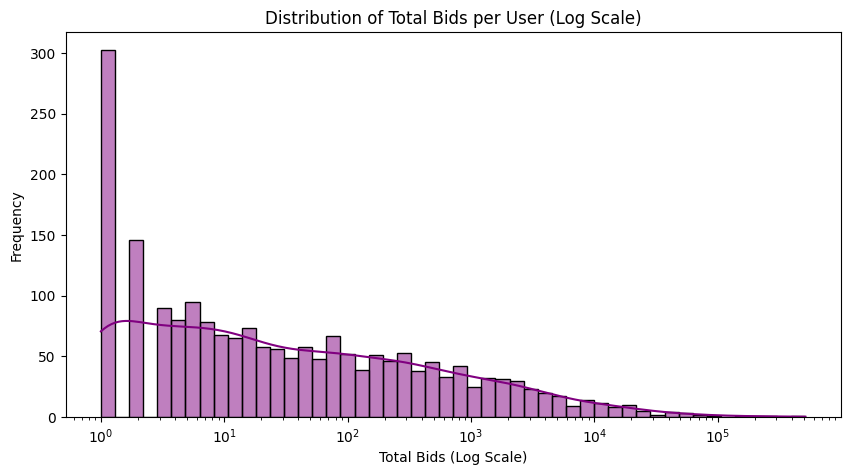

In [15]:
# Plot the distribution of the total number of bids per user on a log scale.
plt.figure(figsize=(10, 5))
sns.histplot(master_df['num_bids'], bins=50, kde=True, log_scale=True, color='purple')
plt.title('Distribution of Total Bids per User (Log Scale)')
plt.xlabel('Total Bids (Log Scale)')
plt.ylabel('Frequency')
plt.show()

The frequency histogram of total bids is heavily right-skewed. The vast majority of users place very few bids, while a long tail of extreme outliers dominates the total volume. Applying a log transformation reveals a secondary peak in the tail, which perfectly matches the immense behavioral footprint of the high-frequency, automated bot population.

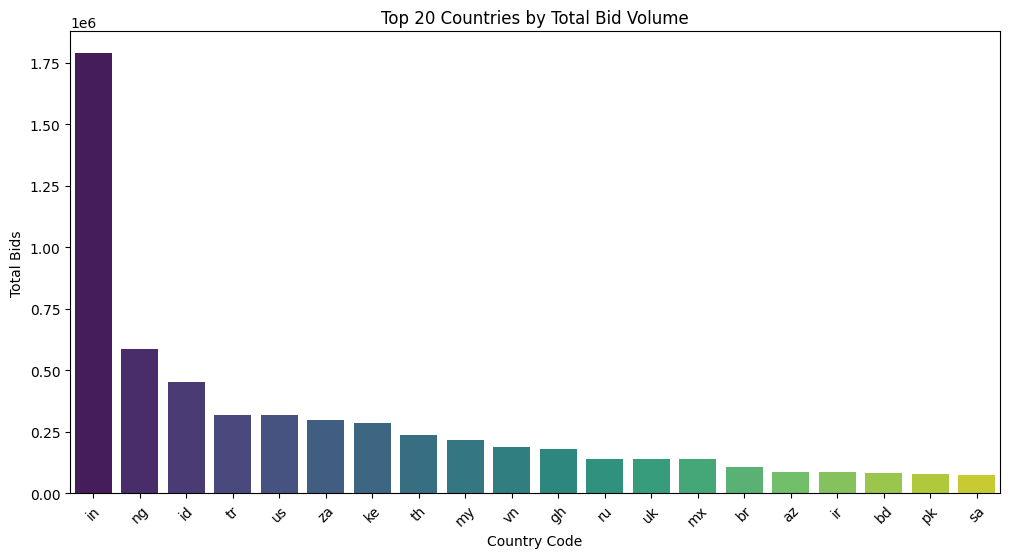

In [16]:
# Display the top 20 countries by total bid volume.
plt.figure(figsize=(12, 6))
top_countries = bids_df['country'].value_counts().head(20)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 20 Countries by Total Bid Volume')
plt.xlabel('Country Code')
plt.ylabel('Total Bids')
plt.xticks(rotation=45)
plt.show()

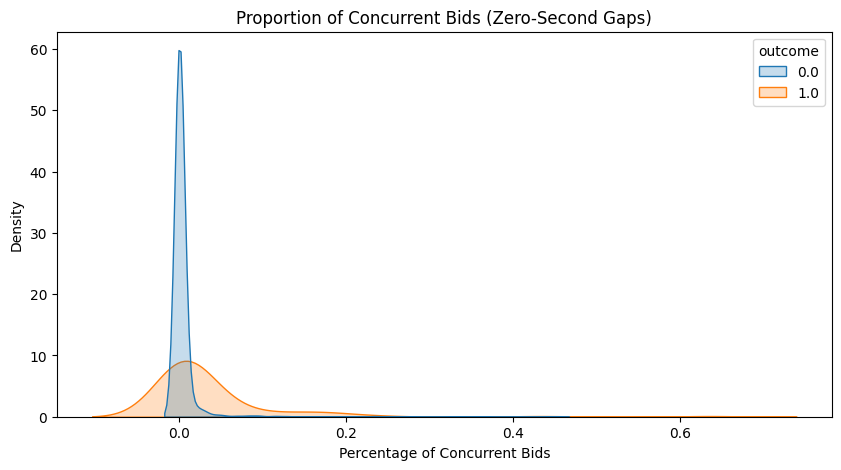

In [17]:
# Plot the distribution of the percentage of concurrent bids (zero-second gaps) for human vs. bot.
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=master_df,
    x='percent_concurrent_bids',
    hue='outcome',
    common_norm=False,
    fill=True
)
plt.title('Proportion of Concurrent Bids (Zero-Second Gaps)')
plt.xlabel('Percentage of Concurrent Bids')
plt.show()

Display a sharp peak near zero because humans rarely place multiple bids at the exact same second, reflecting a natural sequential rhythm where actions occur one after another. This low concurrency causes most human bidders to cluster tightly at very low percentages of concurrent bids. In contrast, bots (labeled as 1) are programmed for efficiency and can execute simultaneous or rapid bids across items, producing a broader spread of concurrency values. As a result, bots show a flatter, more distributed curve rather than a sharp rise.

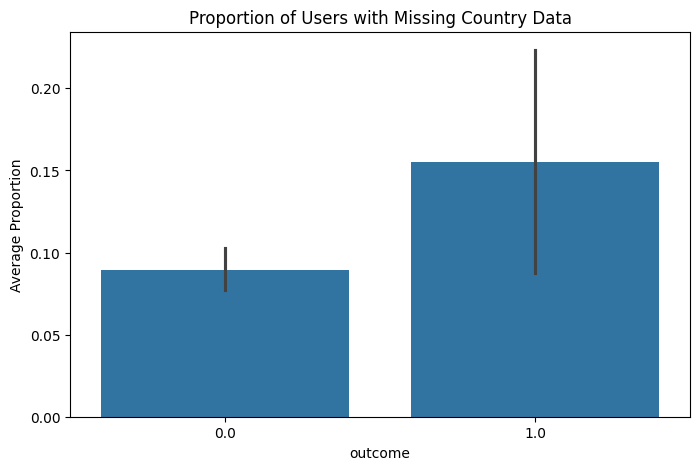

In [18]:
# Analyze the proportion of users with missing country data based on their outcome.
master_df['has_missing_country'] = np.where(
    master_df['missing_country_bids'] > 0, 1, 0
)

plt.figure(figsize=(8, 5))
sns.barplot(x='outcome', y='has_missing_country', data=master_df)
plt.title('Proportion of Users with Missing Country Data')
plt.ylabel('Average Proportion')
plt.show()

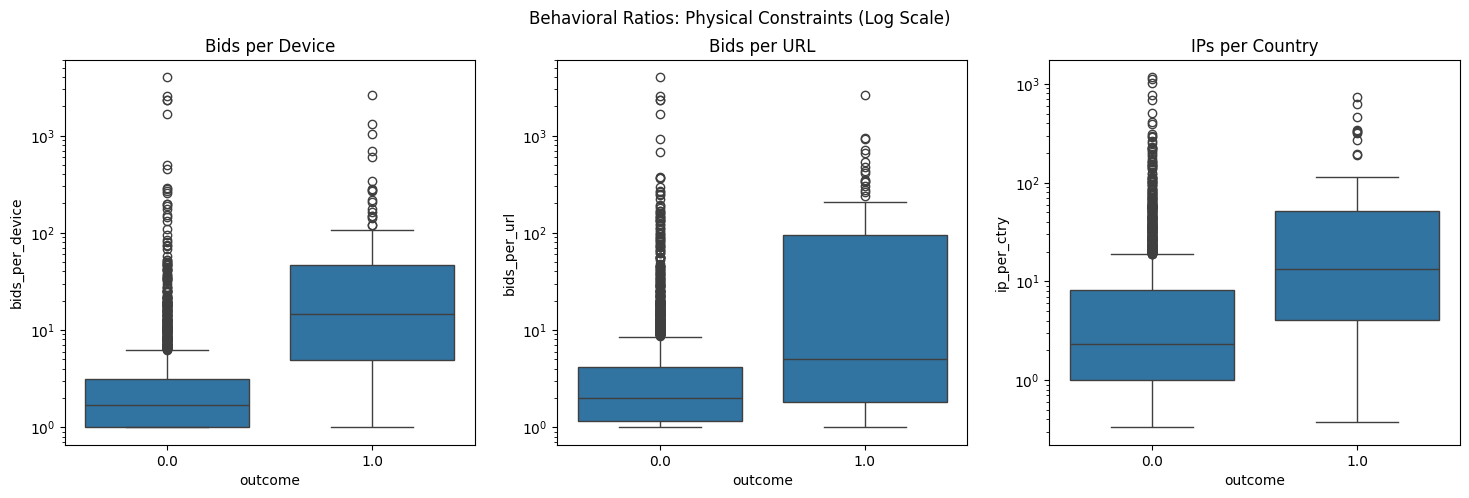

In [19]:
# Visualize behavioral ratios (bids per device, bids per URL, IPs per country) for human vs. bot.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='outcome', y='bids_per_device', data=master_df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Bids per Device')

sns.boxplot(x='outcome', y='bids_per_url', data=master_df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Bids per URL')

sns.boxplot(x='outcome', y='ip_per_ctry', data=master_df, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('IPs per Country')

plt.suptitle('Behavioral Ratios: Physical Constraints (Log Scale)')
plt.show()

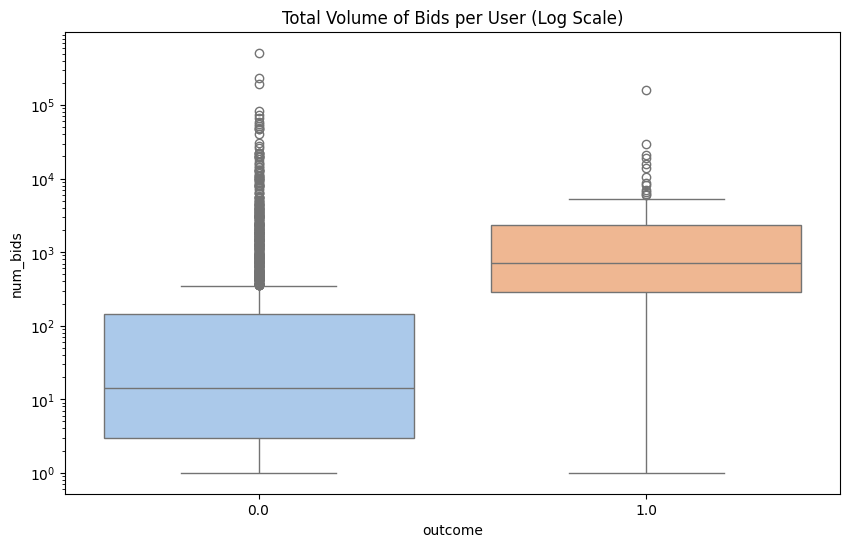

In [20]:
# Compare the total volume of bids per user (on a log scale) for human vs. bot.
plt.figure(figsize=(10, 6))
sns.boxplot(x='outcome', y='num_bids', data=master_df, palette='pastel')
plt.yscale('log')
plt.title('Total Volume of Bids per User (Log Scale)')
plt.show()

The log-scaled boxplot of total bids emphasizes the massive disparity in operational scale. Bots frequently execute hundreds of thousands of bids, creating extreme upward outliers. Humans rarely exceed a few dozen bids. This confirms that pure volume is a strong baseline indicator, though ratio engineering remains necessary to catch lower-volume "sleeper" bots

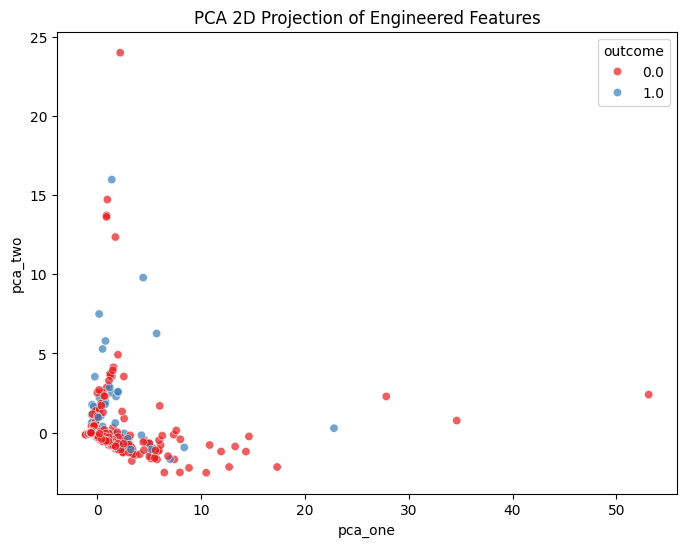

In [21]:
# Apply PCA to a subset of scaled engineered features and visualize the 2D projection, colored by outcome.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    'num_bids',
    'num_auct',
    'num_device',
    'num_ip',
    'num_url',
    'mean_diff',
    'percent_concurrent_bids',
    'bids_per_device',
    'ip_per_ctry'
]

X = master_df[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

master_df['pca_one'] = pca_result[:, 0]
master_df['pca_two'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='pca_one',
    y='pca_two',
    hue='outcome',
    data=master_df,
    alpha=0.7,
    palette='Set1'
)

plt.title('PCA 2D Projection of Engineered Features')
plt.show()

ccczzzzzz

> Add blockquote



In [22]:
# ==========================================
# FEATURE ENGINEERING REBUILD
# ==========================================
print("Rebuilding master_df with full Behavioral Fingerprint...")

# --- STEP 1: Handle Missing Data ---
bids_df['country'] = bids_df['country'].fillna(bids_df['country'].mode()[0])

# --- STEP 2: Basic Uniques (Network Multiplexing & Volume) ---
bidder_unique = bids_df.groupby("bidder_id").nunique().reset_index()
bidder_unique = bidder_unique.rename(columns={
    'bid_id':      'num_bids',
    'auction':     'num_auct',
    'merchandise': 'num_merch_type',
    'device':      'num_device_type',
    'time':        'num_time',
    'country':     'num_ctry',
    'ip':          'num_ip',
    'url':         'num_url'
})
# Rebuild master_df fresh from original train_df (no old merged features)
master_df = train_df[['bidder_id', 'outcome']].copy()
master_df = master_df.merge(bidder_unique, on='bidder_id', how='left').fillna(0)

# --- STEP 3: Time Differences (Precision / Dispersion) ---
time_df = bids_df.sort_values(['bidder_id', 'time'])
time_df['first_diff'] = time_df.groupby('bidder_id')['time'].diff()

firstdiff_feat = time_df[['bidder_id', 'first_diff']].dropna()
bid_intervals = firstdiff_feat.groupby('bidder_id')['first_diff'].describe().reset_index()
bid_intervals = bid_intervals.rename(columns={
    'mean': 'mean_diff', 'std': 'std_diff',
    '50%':  'median_diff', 'min': 'min_diff', 'max': 'max_diff'
}).fillna(0)
bid_intervals['iqr_diff'] = bid_intervals['75%'] - bid_intervals['25%']
bid_intervals = bid_intervals.drop(columns=['25%', '75%', 'count'], errors='ignore')

master_df = master_df.merge(bid_intervals, on='bidder_id', how='left').fillna(0)

# --- STEP 4: Concurrent Bids (Bot Speed) ---
concurrent_bids = firstdiff_feat[firstdiff_feat['first_diff'] == 0] \
    .groupby('bidder_id').size().reset_index(name='num_concurrent_bids')
master_df = master_df.merge(concurrent_bids, on='bidder_id', how='left').fillna(0)

# --- STEP 5: First and Last Bids (Bid Sniping Behavior) ---
first_bid = bids_df.sort_values(['auction', 'time']).groupby('auction').first() \
    .groupby('bidder_id').size().reset_index(name='num_first_bid')
last_bid  = bids_df.sort_values(['auction', 'time']).groupby('auction').last() \
    .groupby('bidder_id').size().reset_index(name='num_last_bid')
master_df = master_df.merge(first_bid, on='bidder_id', how='left').fillna(0)
master_df = master_df.merge(last_bid,  on='bidder_id', how='left').fillna(0)

# --- STEP 6: Auction Time Halves (When do they bid?) ---
auct_duration = bids_df.groupby('auction')['time'].agg(['max', 'min']).reset_index()
auct_duration['auct_duration'] = auct_duration['max'] - auct_duration['min']

time_ratio = bids_df[['bidder_id', 'auction', 'time']].merge(auct_duration, on='auction', how='left')
time_ratio['temp']      = time_ratio['time'] - time_ratio['auct_duration'] / 2
time_ratio['firsthalf'] = time_ratio['temp'] < time_ratio['min']

ratio_firsthalf = time_ratio.groupby('bidder_id')['firsthalf'] \
    .agg(['count', 'sum']).reset_index() \
    .rename(columns={'count': 'num_total_bids', 'sum': 'num_firsthalf_bids'})
ratio_firsthalf['num_secondhalf_bids']      = ratio_firsthalf['num_total_bids'] - ratio_firsthalf['num_firsthalf_bids']
ratio_firsthalf['percent_firsthalf_bids']   = ratio_firsthalf['num_firsthalf_bids']  / ratio_firsthalf['num_total_bids']
ratio_firsthalf['percent_secondhalf_bids']  = ratio_firsthalf['num_secondhalf_bids'] / ratio_firsthalf['num_total_bids']
ratio_firsthalf = ratio_firsthalf.drop(columns=['num_total_bids'])

master_df = master_df.merge(ratio_firsthalf, on='bidder_id', how='left').fillna(0)

# --- STEP 7: Max Bids in a Single Auction ---
max_bids_in_auct = bids_df.groupby(['bidder_id', 'auction']).size().reset_index(name='bids_in_auct')
max_bids_in_auct = max_bids_in_auct.groupby('bidder_id')['bids_in_auct'].max().reset_index(name='max_bids_in_auct')
master_df = master_df.merge(max_bids_in_auct, on='bidder_id', how='left').fillna(0)

# --- STEP 8: Device Aggressiveness ---
device      = bids_df.groupby(['bidder_id', 'device'])['auction'].nunique().reset_index(name='num_auct_per_device')
device_bids = bids_df.groupby(['bidder_id', 'device']).size().reset_index(name='max_bids_per_device')
device      = device.merge(device_bids, on=['bidder_id', 'device'])
device      = device.groupby('bidder_id')[['max_bids_per_device', 'num_auct_per_device']].max().reset_index()
device['max_bids_per_device_per_auct'] = device['max_bids_per_device'] / device['num_auct_per_device'].replace(0, 1)
device      = device[['bidder_id', 'max_bids_per_device', 'max_bids_per_device_per_auct']]
master_df   = master_df.merge(device, on='bidder_id', how='left').fillna(0)

# --- STEP 9: Master Ratios (The Final Key Features) ---
master_df['percent_concurrent_bids'] = master_df['num_concurrent_bids'] / master_df['num_bids'].replace(0, 1)
master_df['bids_per_auct']           = master_df['num_bids']             / master_df['num_auct'].replace(0, 1)
master_df['bids_per_device']         = master_df['num_bids']             / master_df['num_device_type'].replace(0, 1)
master_df['bids_per_url']            = master_df['num_bids']             / master_df['num_url'].replace(0, 1)
master_df['device_per_auct']         = master_df['num_device_type']      / master_df['num_auct'].replace(0, 1)
master_df['ip_per_ctry']             = master_df['num_ip']               / master_df['num_ctry'].replace(0, 1)
master_df['percent_max_bids']        = master_df['max_bids_per_device']  / master_df['num_bids'].replace(0, 1)
master_df = master_df.fillna(0)

print(f"✅ Rebuild Complete. Final master_df shape: {master_df.shape}")
print(f"   Features: {list(master_df.drop(columns=['bidder_id','outcome']).columns)}")

Rebuilding master_df with full Behavioral Fingerprint...
✅ Rebuild Complete. Final master_df shape: (2013, 34)
   Features: ['num_bids', 'num_auct', 'num_merch_type', 'num_device_type', 'num_time', 'num_ctry', 'num_ip', 'num_url', 'time_diff', 'mean_diff', 'std_diff', 'min_diff', 'median_diff', 'max_diff', 'iqr_diff', 'num_concurrent_bids', 'num_first_bid', 'num_last_bid', 'num_firsthalf_bids', 'num_secondhalf_bids', 'percent_firsthalf_bids', 'percent_secondhalf_bids', 'max_bids_in_auct', 'max_bids_per_device', 'max_bids_per_device_per_auct', 'percent_concurrent_bids', 'bids_per_auct', 'bids_per_device', 'bids_per_url', 'device_per_auct', 'ip_per_ctry', 'percent_max_bids']


In [23]:
import pandas as pd
from google.colab import files

# 1. Dataset Info
print("--- Dataset Info ---")
print(master_df.info())

# 2. First 5 rows
print("\n--- First 5 Rows ---")
display(master_df.head())

# 3. Last 5 rows
print("\n--- Last 5 Rows ---")
display(master_df.tail())

# 4. Shape of the dataset
print(f"\nDataset Shape: {master_df.shape}")

# 5. Descriptive Statistics
print("\n--- Descriptive Statistics ---")
display(master_df.describe())

# 6. Check for Missing Values
print("\n--- Missing Values Count ---")
print(master_df.isnull().sum())

# 7. Column Names
print("\n--- Column List ---")
print(master_df.columns.tolist())

# --- Save and Download ---
final_filename = 'final_master_df.csv'
master_df.to_csv(final_filename, index=False)
print(f"\nSaved as {final_filename}. Triggering download...")
files.download(final_filename)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2013 entries, 0 to 2012
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bidder_id                     2013 non-null   object 
 1   outcome                       2013 non-null   float64
 2   num_bids                      2013 non-null   float64
 3   num_auct                      2013 non-null   float64
 4   num_merch_type                2013 non-null   float64
 5   num_device_type               2013 non-null   float64
 6   num_time                      2013 non-null   float64
 7   num_ctry                      2013 non-null   float64
 8   num_ip                        2013 non-null   float64
 9   num_url                       2013 non-null   float64
 10  time_diff                     2013 non-null   float64
 11  mean_diff                     2013 non-null   float64
 12  std_diff                      2013 non-nu

,bidder_id,outcome,num_bids,num_auct,num_merch_type,num_device_type,num_time,num_ctry,num_ip,num_url,...,max_bids_in_auct,max_bids_per_device,max_bids_per_device_per_auct,percent_concurrent_bids,bids_per_auct,bids_per_device,bids_per_url,device_per_auct,ip_per_ctry,percent_max_bids
0,91a3c57b13234af24875c56fb7e2b2f4rb56a,0.0,24.0,18.0,1.0,14.0,24.0,6.0,20.0,1.0,...,3.0,6.0,1.0,0.0,1.333333,1.714286,24.000000,0.777778,3.333333,0.250000
1,624f258b49e77713fc34034560f93fb3hu3jo,0.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,2.0,...,3.0,2.0,2.0,0.0,3.000000,1.500000,1.500000,2.000000,3.000000,0.666667
2,1c5f4fc669099bfbfac515cd26997bd12ruaj,0.0,4.0,4.0,1.0,2.0,4.0,1.0,4.0,2.0,...,1.0,3.0,1.0,0.0,1.000000,2.000000,2.000000,0.500000,4.000000,0.750000
3,4bee9aba2abda51bf43d639013d6efe12iycd,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,4ab12bc61c82ddd9c2d65e60555808acqgos1,0.0,155.0,23.0,1.0,53.0,155.0,2.0,123.0,91.0,...,38.0,19.0,3.8,0.0,6.739130,2.924528,1.703297,2.304348,61.500000,0.122581



--- Last 5 Rows ---


,bidder_id,outcome,num_bids,num_auct,num_merch_type,num_device_type,num_time,num_ctry,num_ip,num_url,...,max_bids_in_auct,max_bids_per_device,max_bids_per_device_per_auct,percent_concurrent_bids,bids_per_auct,bids_per_device,bids_per_url,device_per_auct,ip_per_ctry,percent_max_bids
2008,369515b3af4f8ca582f90271d30b14b6r52aw,0.0,36.0,25.0,1.0,4.0,33.0,4.0,5.0,2.0,...,4.0,33.0,1.5,0.083333,1.44,9.0,18.0,0.16,1.25,0.916667
2009,f939c17ffc7c39ac9b35b69e5e75179fv9pe2,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.000000,1.00,1.0,1.0,1.00,1.00,1.000000
2010,c806dbb2decba0ed3c4ff5e2e60a74c2wjvbl,0.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,...,2.0,1.0,1.0,0.000000,2.00,1.0,2.0,2.00,2.00,0.500000
2011,0381a69b7a061e9ace2798fd48f1f537mgq57,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.000000,1.00,1.0,1.0,1.00,1.00,1.000000
2012,84a769adc98498f52debfe57b93a0789556f4,0.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,...,2.0,2.0,2.0,0.000000,2.00,2.0,2.0,1.00,1.00,1.000000



Dataset Shape: (2013, 34)

--- Descriptive Statistics ---


,outcome,num_bids,num_auct,num_merch_type,num_device_type,num_time,num_ctry,num_ip,num_url,time_diff,...,max_bids_in_auct,max_bids_per_device,max_bids_per_device_per_auct,percent_concurrent_bids,bids_per_auct,bids_per_device,bids_per_url,device_per_auct,ip_per_ctry,percent_max_bids
count,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,...,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000
mean,0.051167,1525.694983,61.684054,0.986090,77.469945,1286.513661,13.112767,665.318430,341.072529,143.808743,...,237.932936,218.030800,4.332131,0.006544,7.203895,16.682735,20.576380,1.369014,19.626668,0.422861
std,0.220394,14596.346369,146.431311,0.121313,186.608609,9553.090044,23.321031,4756.459187,2657.945875,244.395663,...,1896.041145,1907.239514,13.742023,0.033462,30.794075,153.518871,156.101360,2.612676,84.154523,0.345909
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,2.000000,1.000000,2.000000,3.000000,1.000000,2.000000,1.000000,2.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.147059,0.800000,1.200000,0.131868
50%,0.000000,17.000000,10.000000,1.000000,8.000000,16.000000,3.000000,12.000000,5.000000,15.000000,...,4.000000,4.000000,1.333333,0.000000,1.681818,1.766667,2.000000,1.000000,3.142857,0.285714
75%,0.000000,200.000000,45.000000,1.000000,57.000000,200.000000,12.000000,112.000000,38.000000,157.000000,...,31.000000,31.000000,2.687500,0.000000,4.221122,3.545918,4.500000,1.285714,10.540000,0.666667
max,1.000000,515033.000000,1623.000000,2.000000,2618.000000,283463.000000,178.000000,111918.000000,81376.000000,1012.000000,...,62485.000000,67769.000000,224.500000,0.635762,1023.500000,3976.000000,3976.000000,81.000000,1753.000000,1.000000



--- Missing Values Count ---
bidder_id                       0
outcome                         0
num_bids                        0
num_auct                        0
num_merch_type                  0
num_device_type                 0
num_time                        0
num_ctry                        0
num_ip                          0
num_url                         0
time_diff                       0
mean_diff                       0
std_diff                        0
min_diff                        0
median_diff                     0
max_diff                        0
iqr_diff                        0
num_concurrent_bids             0
num_first_bid                   0
num_last_bid                    0
num_firsthalf_bids              0
num_secondhalf_bids             0
percent_firsthalf_bids          0
percent_secondhalf_bids         0
max_bids_in_auct                0
max_bids_per_device             0
max_bids_per_device_per_auct    0
percent_concurrent_bids         0
bids_per_auct     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

X = master_df.drop(columns=['bidder_id', 'outcome'])
y = master_df['outcome']

In [25]:
# ---------------------------------------------------------
# TASK 2: VALIDATION - HOLDOUT METHOD
# ---------------------------------------------------------
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data successfully split into Train and Test sets!")

Data successfully split into Train and Test sets!


In [26]:
# ---------------------------------------------------------
# TASK 1: TRAIN MINIMUM 5 MODELS
# ---------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "AdaBoost":            AdaBoostClassifier(random_state=42),
    "XGBoost":             XGBClassifier(eval_metric='logloss', random_state=42)
}

print("--- Initial Holdout AUC Scores ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, preds)
    print(f"{name}: {auc:.4f}")

--- Initial Holdout AUC Scores ---
Logistic Regression: 0.7797
Decision Tree: 0.7563
Random Forest: 0.9455
AdaBoost: 0.9334
XGBoost: 0.9336


In [27]:
# ---------------------------------------------------------
# TASK 2: CROSS VALIDATION (K-FOLD = 5)
# ---------------------------------------------------------
print("\n--- 5-Fold Cross Validation (AUC) ---")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    print(f"{name} CV Mean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


--- 5-Fold Cross Validation (AUC) ---
Logistic Regression CV Mean AUC: 0.7441 (+/- 0.0472)
Decision Tree CV Mean AUC: 0.6129 (+/- 0.0677)
Random Forest CV Mean AUC: 0.9138 (+/- 0.0211)
AdaBoost CV Mean AUC: 0.9101 (+/- 0.0317)
XGBoost CV Mean AUC: 0.9132 (+/- 0.0227)


In [28]:
# ---------------------------------------------------------
# TASK 4: GRID SEARCH CV (Optimizing Random Forest)
# ---------------------------------------------------------
print("\n--- Running Grid Search CV on Random Forest ---")
rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best RF AUC: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.4f}")


--- Running Grid Search CV on Random Forest ---
Best RF AUC: 0.9360


In [29]:
# ---------------------------------------------------------
# TASK 5: RANDOMIZED SEARCH CV (Optimizing XGBoost)
# ---------------------------------------------------------
print("\n--- Running Randomized Search CV on XGBoost ---")
xgb_params = {
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [3, 5, 7],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'n_estimators':     [100, 200, 300]
}
random_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params, n_iter=15, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)

best_xgb    = random_search.best_estimator_
final_preds = best_xgb.predict(X_test)
final_probs = best_xgb.predict_proba(X_test)[:, 1]
print(f"Best XGBoost AUC: {roc_auc_score(y_test, final_probs):.4f}")


--- Running Randomized Search CV on XGBoost ---
Best XGBoost AUC: 0.9371


In [30]:
print("\n--- Running Grid Search CV for Logistic Regression ---")
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_search_logreg = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), logreg_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_logreg.fit(X_train, y_train)

best_logreg = grid_search_logreg.best_estimator_
print(f"Best Logistic Regression AUC: {roc_auc_score(y_test, best_logreg.predict_proba(X_test)[:, 1]):.4f}")
print(f"Best Logistic Regression Params: {grid_search_logreg.best_params_}")


--- Running Grid Search CV for Logistic Regression ---
Best Logistic Regression AUC: 0.7797
Best Logistic Regression Params: {'C': 0.01, 'solver': 'lbfgs'}


In [31]:
print("\n--- Running Grid Search CV for Decision Tree ---")
dtc_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dtc = GridSearchCV(DecisionTreeClassifier(random_state=42), dtc_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_dtc.fit(X_train, y_train)

best_dtc = grid_search_dtc.best_estimator_
print(f"Best Decision Tree AUC: {roc_auc_score(y_test, best_dtc.predict_proba(X_test)[:, 1]):.4f}")
print(f"Best Decision Tree Params: {grid_search_dtc.best_params_}")




--- Running Grid Search CV for Decision Tree ---
Best Decision Tree AUC: 0.8915
Best Decision Tree Params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [32]:
print("\n--- Running Grid Search CV for AdaBoost ---")
adaboost_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
grid_search_ada = GridSearchCV(AdaBoostClassifier(random_state=42), adaboost_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_ada.fit(X_train, y_train)

best_ada = grid_search_ada.best_estimator_
print(f"Best AdaBoost AUC: {roc_auc_score(y_test, best_ada.predict_proba(X_test)[:, 1]):.4f}")
print(f"Best AdaBoost Params: {grid_search_ada.best_params_}")


--- Running Grid Search CV for AdaBoost ---
Best AdaBoost AUC: 0.9167
Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 200}


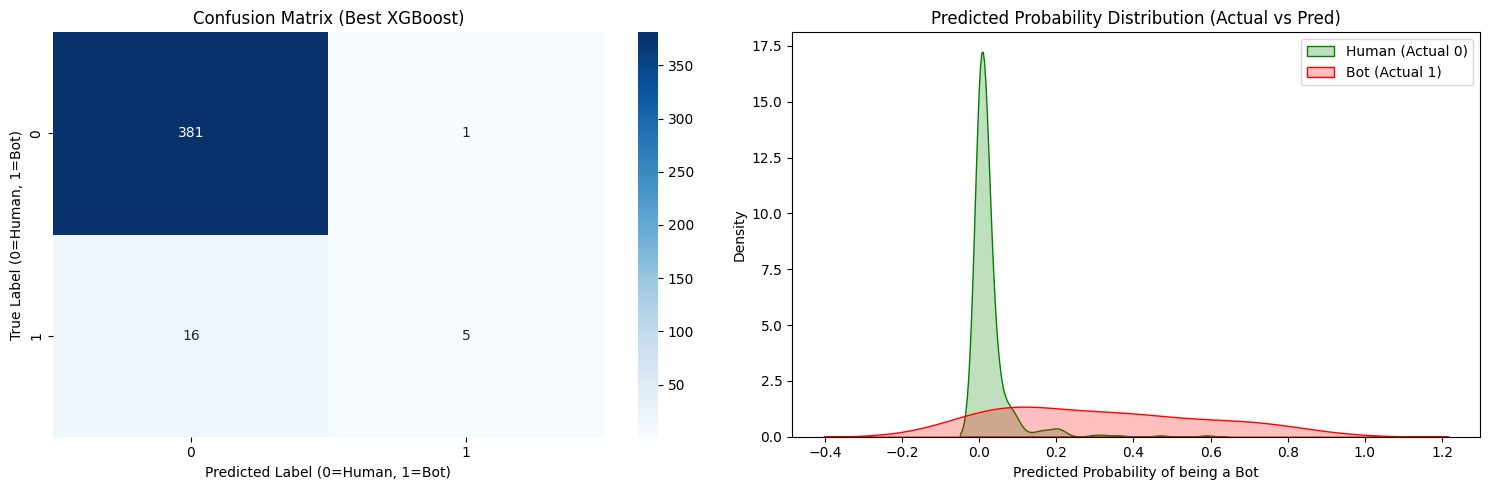

In [33]:
# ---------------------------------------------------------
# TASK 6 & 7: EVALUATION GRAPHS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Best XGBoost)')
axes[0].set_xlabel('Predicted Label (0=Human, 1=Bot)')
axes[0].set_ylabel('True Label (0=Human, 1=Bot)')

# 2. Predicted Probability Distribution
sns.kdeplot(final_probs[y_test == 0], label='Human (Actual 0)', fill=True, color='green', ax=axes[1])
sns.kdeplot(final_probs[y_test == 1], label='Bot (Actual 1)',   fill=True, color='red',   ax=axes[1])
axes[1].set_title('Predicted Probability Distribution (Actual vs Pred)')
axes[1].set_xlabel('Predicted Probability of being a Bot')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

Train bot ratio : 0.051
Test  bot ratio : 0.052
Bots in test set: 21

APPROACH 1: Threshold Tuning on Existing XGBoost
Base AUC: 0.9336

Default threshold : 0.50
Best F1 threshold : 0.0934

  [Default (0.50)]
    TN=378  FP=4  FN=15  TP=6
    Bot Recall = 0.286  |  AUC = 0.9336

  [Optimal (0.09)]
    TN=370  FP=12  FN=7  TP=14
    Bot Recall = 0.667  |  AUC = 0.9336


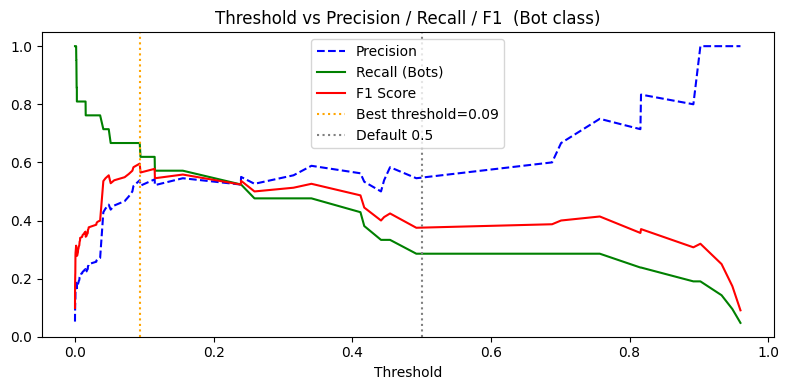

  ✅ Saved: threshold_tuning.png

APPROACH 2: XGBoost with scale_pos_weight
scale_pos_weight = 1528/82 = 18.6

  AUC          : 0.9339
  TN=374  FP=8  FN=9  TP=12
  Bot Recall   : 0.571

  [Weighted XGB + Optimal threshold=0.57]
  TN=375  FP=7  FN=9  TP=12
  Bot Recall = 0.571

APPROACH 3: SMOTE Oversampling + XGBoost
After SMOTE — train size: 3056
Bot ratio in SMOTE train: 0.500

  AUC          : 0.9256
  TN=369  FP=13  FN=10  TP=11
  Bot Recall   : 0.524

  [SMOTE XGB + Optimal threshold=0.68]
  TN=376  FP=6  FN=10  TP=11
  Bot Recall = 0.524

FINAL COMPARISON
Model                                  AUC   FN   TP  Bot Recall
-----------------------------------------------------------------
1. Base XGB (thresh=0.50)           0.9336   15    6       0.286
1b. Base XGB (thresh opt)           0.9336    7   14       0.667
2. Weighted XGB (thresh=0.50)       0.9339    9   12       0.571
2b. Weighted XGB (thresh opt)       0.9339    9   12       0.571
3. SMOTE XGB (thresh=0.50)          0.925

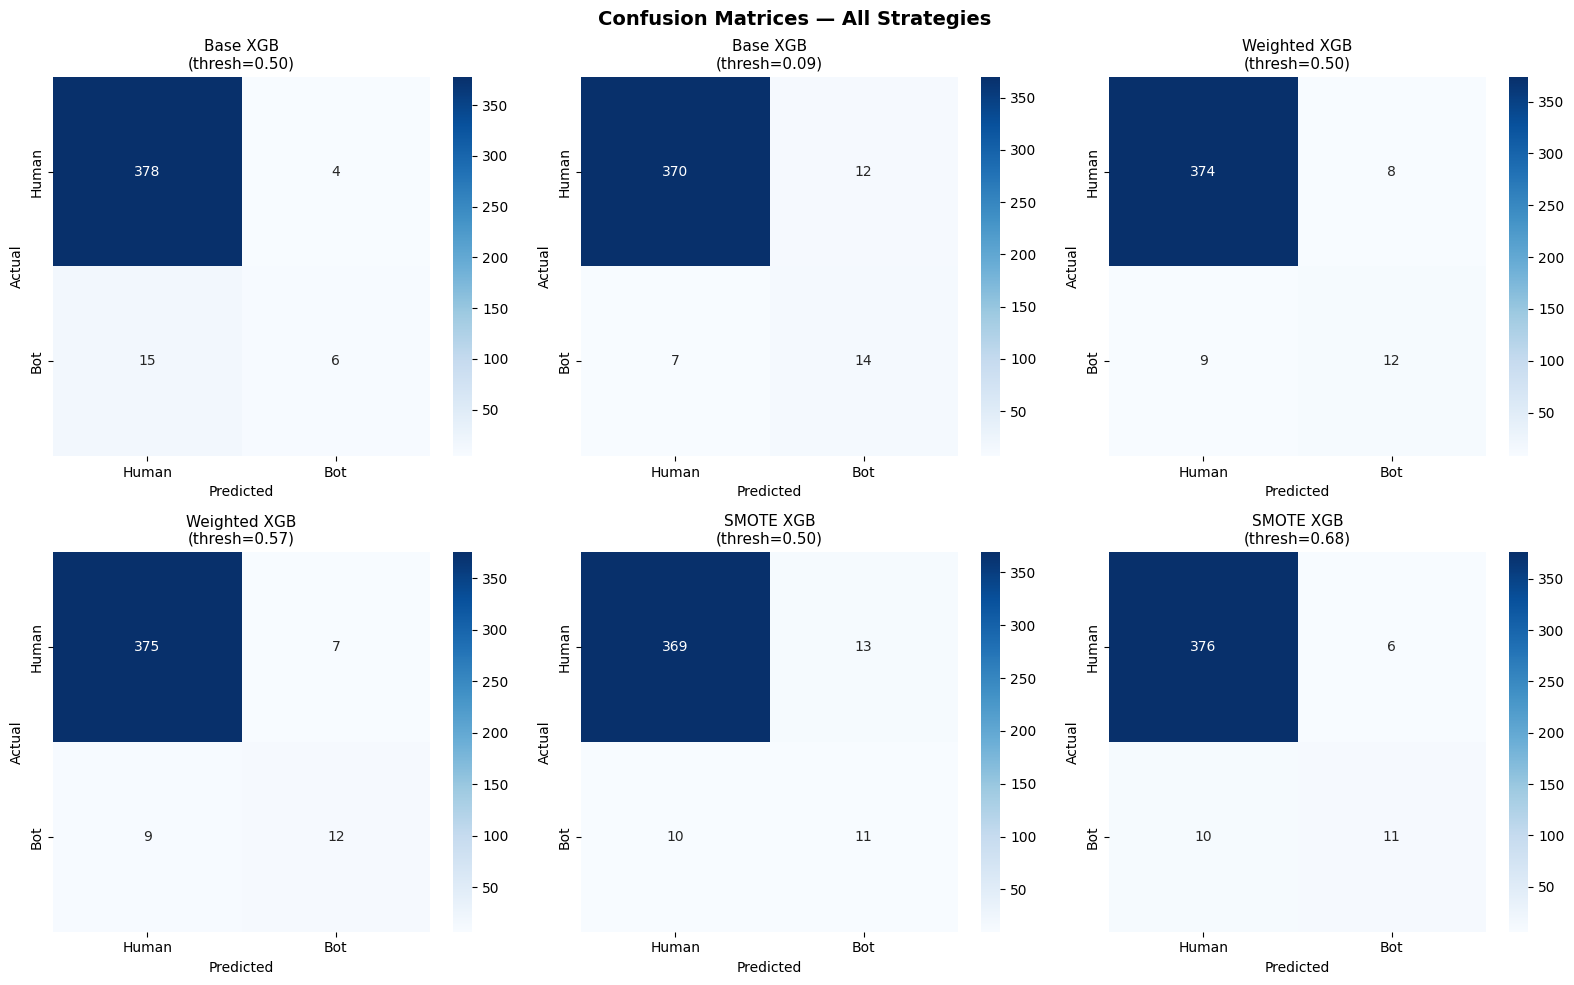

✅ Saved: confusion_matrix_all.png


In [34]:
# ============================================================
#  HUMAN OR BOT — Fixing Class Imbalance (FN Reduction)
#  3-Layer Strategy:
#   1. Threshold Tuning      (no retraining needed)
#   2. scale_pos_weight XGB  (training-time fix)
#   3. SMOTE + XGB           (data-level fix)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, f1_score,
                             precision_recall_curve, recall_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# NOTE: Assumes `master_df` is already built
# from your existing feature engineering code.
# If running fresh, run your notebook cells
# first to create master_df.
# ─────────────────────────────────────────────

X = master_df.drop(columns=['bidder_id', 'outcome'])
y = master_df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train bot ratio : {y_train.mean():.3f}")
print(f"Test  bot ratio : {y_test.mean():.3f}")
print(f"Bots in test set: {int(y_test.sum())}")


# ════════════════════════════════════════════════════
# APPROACH 1 — THRESHOLD TUNING (your existing model)
# ════════════════════════════════════════════════════
print("\n" + "="*55)
print("APPROACH 1: Threshold Tuning on Existing XGBoost")
print("="*55)

# Re-train your best XGBoost (same params you found via RandomizedSearchCV)
base_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
base_xgb.fit(X_train, y_train)

probs = base_xgb.predict_proba(X_test)[:, 1]
base_auc = roc_auc_score(y_test, probs)
print(f"Base AUC: {base_auc:.4f}")

# --- Find the best threshold by maximising F1 for bots (class 1) ---
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"\nDefault threshold : 0.50")
print(f"Best F1 threshold : {best_thresh:.4f}")

# --- Compare confusion matrices ---
for label, thresh in [("Default (0.50)", 0.50), (f"Optimal ({best_thresh:.2f})", best_thresh)]:
    preds = (probs >= thresh).astype(int)
    cm    = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    recall_bots = tp / (tp + fn + 1e-8)
    print(f"\n  [{label}]")
    print(f"    TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"    Bot Recall = {recall_bots:.3f}  |  AUC = {base_auc:.4f}")

# --- Precision-Recall curve plot ---
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1],    'g-',  label='Recall (Bots)')
plt.plot(thresholds, f1_scores[:-1],  'r-',  label='F1 Score')
plt.axvline(best_thresh, color='orange', linestyle=':', label=f'Best threshold={best_thresh:.2f}')
plt.axvline(0.5,         color='gray',   linestyle=':', label='Default 0.5')
plt.xlabel('Threshold')
plt.title('Threshold vs Precision / Recall / F1  (Bot class)')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150)
plt.show()
print("  ✅ Saved: threshold_tuning.png")


# ════════════════════════════════════════════════════
# APPROACH 2 — scale_pos_weight (XGBoost native)
# ════════════════════════════════════════════════════
print("\n" + "="*55)
print("APPROACH 2: XGBoost with scale_pos_weight")
print("="*55)

# scale_pos_weight = #negatives / #positives  (standard rule)
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {spw:.1f}")

xgb_weighted = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_weighted.fit(X_train, y_train)

probs_w  = xgb_weighted.predict_proba(X_test)[:, 1]
preds_w  = xgb_weighted.predict(X_test)
auc_w    = roc_auc_score(y_test, probs_w)

cm_w          = confusion_matrix(y_test, preds_w)
tn_w, fp_w, fn_w, tp_w = cm_w.ravel()
recall_bots_w = tp_w / (tp_w + fn_w + 1e-8)

print(f"\n  AUC          : {auc_w:.4f}")
print(f"  TN={tn_w}  FP={fp_w}  FN={fn_w}  TP={tp_w}")
print(f"  Bot Recall   : {recall_bots_w:.3f}")

# --- Also apply threshold tuning on top of weighted model ---
precisions_w, recalls_w, thresholds_w = precision_recall_curve(y_test, probs_w)
f1_w     = 2 * (precisions_w * recalls_w) / (precisions_w + recalls_w + 1e-8)
best_idx_w  = np.argmax(f1_w)
best_thresh_w = thresholds_w[best_idx_w] if best_idx_w < len(thresholds_w) else 0.5
preds_w_opt  = (probs_w >= best_thresh_w).astype(int)
cm_w_opt     = confusion_matrix(y_test, preds_w_opt)
tn_wo, fp_wo, fn_wo, tp_wo = cm_w_opt.ravel()

print(f"\n  [Weighted XGB + Optimal threshold={best_thresh_w:.2f}]")
print(f"  TN={tn_wo}  FP={fp_wo}  FN={fn_wo}  TP={tp_wo}")
print(f"  Bot Recall = {tp_wo/(tp_wo+fn_wo+1e-8):.3f}")


# ════════════════════════════════════════════════════
# APPROACH 3 — SMOTE + XGBoost
# ════════════════════════════════════════════════════
print("\n" + "="*55)
print("APPROACH 3: SMOTE Oversampling + XGBoost")
print("="*55)

# SMOTE: only applied to TRAINING data, never test
sm            = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"After SMOTE — train size: {len(y_train_sm)}")
print(f"Bot ratio in SMOTE train: {y_train_sm.mean():.3f}")

xgb_smote = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_smote.fit(X_train_sm, y_train_sm)

probs_s  = xgb_smote.predict_proba(X_test)[:, 1]
preds_s  = xgb_smote.predict(X_test)
auc_s    = roc_auc_score(y_test, probs_s)

cm_s          = confusion_matrix(y_test, preds_s)
tn_s, fp_s, fn_s, tp_s = cm_s.ravel()
recall_bots_s = tp_s / (tp_s + fn_s + 1e-8)

print(f"\n  AUC          : {auc_s:.4f}")
print(f"  TN={tn_s}  FP={fp_s}  FN={fn_s}  TP={tp_s}")
print(f"  Bot Recall   : {recall_bots_s:.3f}")

# Optimal threshold on SMOTE model too
precisions_s, recalls_s, thresholds_s = precision_recall_curve(y_test, probs_s)
f1_s        = 2 * (precisions_s * recalls_s) / (precisions_s + recalls_s + 1e-8)
best_idx_s  = np.argmax(f1_s)
best_thresh_s = thresholds_s[best_idx_s] if best_idx_s < len(thresholds_s) else 0.5
preds_s_opt  = (probs_s >= best_thresh_s).astype(int)
cm_s_opt     = confusion_matrix(y_test, preds_s_opt)
tn_so, fp_so, fn_so, tp_so = cm_s_opt.ravel()

print(f"\n  [SMOTE XGB + Optimal threshold={best_thresh_s:.2f}]")
print(f"  TN={tn_so}  FP={fp_so}  FN={fn_so}  TP={tp_so}")
print(f"  Bot Recall = {tp_so/(tp_so+fn_so+1e-8):.3f}")


# ════════════════════════════════════════════════════
# FINAL COMPARISON TABLE
# ════════════════════════════════════════════════════
print("\n" + "="*65)
print("FINAL COMPARISON")
print("="*65)
print(f"{'Model':<35} {'AUC':>6} {'FN':>4} {'TP':>4} {'Bot Recall':>11}")
print("-"*65)

# Baseline
base_preds = (probs >= 0.5).astype(int)
cm_b = confusion_matrix(y_test, base_preds)
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
print(f"{'1. Base XGB (thresh=0.50)':<35} {base_auc:>6.4f} {fn_b:>4} {tp_b:>4} {tp_b/(tp_b+fn_b+1e-8):>11.3f}")

base_opt_preds = (probs >= best_thresh).astype(int)
cm_bo = confusion_matrix(y_test, base_opt_preds)
tn_bo, fp_bo, fn_bo, tp_bo = cm_bo.ravel()
print(f"{'1b. Base XGB (thresh opt)':<35} {base_auc:>6.4f} {fn_bo:>4} {tp_bo:>4} {tp_bo/(tp_bo+fn_bo+1e-8):>11.3f}")

print(f"{'2. Weighted XGB (thresh=0.50)':<35} {auc_w:>6.4f} {fn_w:>4} {tp_w:>4} {recall_bots_w:>11.3f}")
print(f"{'2b. Weighted XGB (thresh opt)':<35} {auc_w:>6.4f} {fn_wo:>4} {tp_wo:>4} {tp_wo/(tp_wo+fn_wo+1e-8):>11.3f}")
print(f"{'3. SMOTE XGB (thresh=0.50)':<35} {auc_s:>6.4f} {fn_s:>4} {tp_s:>4} {recall_bots_s:>11.3f}")
print(f"{'3b. SMOTE XGB (thresh opt)':<35} {auc_s:>6.4f} {fn_so:>4} {tp_so:>4} {tp_so/(tp_so+fn_so+1e-8):>11.3f}")
print("="*65)
print("\n✅ Best pick: highest Bot Recall with acceptable FP (look at 2b or 3b)")


# ════════════════════════════════════════════════════
# COMBINED CONFUSION MATRIX PLOT
# ════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
configs = [
    ("Base XGB\n(thresh=0.50)",       confusion_matrix(y_test, (probs  >= 0.50).astype(int))),
    (f"Base XGB\n(thresh={best_thresh:.2f})", confusion_matrix(y_test, (probs  >= best_thresh).astype(int))),
    ("Weighted XGB\n(thresh=0.50)",   confusion_matrix(y_test, preds_w)),
    (f"Weighted XGB\n(thresh={best_thresh_w:.2f})", cm_w_opt),
    ("SMOTE XGB\n(thresh=0.50)",      confusion_matrix(y_test, preds_s)),
    (f"SMOTE XGB\n(thresh={best_thresh_s:.2f})", cm_s_opt),
]

for ax, (title, cm) in zip(axes.flat, configs):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human','Bot'], yticklabels=['Human','Bot'])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Strategies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_all.png', dpi=150)
plt.show()
print("✅ Saved: confusion_matrix_all.png")

In [43]:
import joblib
import os
from google.colab import files

# Define the target directory and filename
model_dir = '/content/drive/MyDrive/models'
model_filename = 'base_xgb_thresh_opt_model.pkl'   # Save as .pkl
model_path = os.path.join(model_dir, model_filename)

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save the trained base_xgb model in .pkl format
joblib.dump(base_xgb, model_path)

print(f"Model 'Base XGB (thresh opt)' saved successfully to: {model_path}")

# Download the file to your local machine
files.download(model_path)


Model 'Base XGB (thresh opt)' saved successfully to: /content/drive/MyDrive/models/base_xgb_thresh_opt_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>